In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

import pyccl as ccl

from scipy.special import jv
from scipy.integrate import romb

import treecorr

In [2]:
#load in flagship sim data
from astropy.io import fits

# fits_file = fits.util.get_testdata_filepath("23586.fits")
hdul = fits.open("/home/milan/Desktop/thesis/flagship_sim/23778.fits")
hdul.info()
hdr = hdul[1].header
data = hdul[1].data

z = data['true_redshift_gal']

# ra = data['ra_gal']
# dec = data['dec_gal']
# print(np.min(ra), np.max(ra))
# print(np.min(dec), np.max(dec))

#create mask in redshift:
z_min = 0.8
z_max = 1
#create mask in ra dec
# ra_min = 
mask = np.where((z > z_min) & (z < z_max))
z = z[mask]

# x = data['x_gal'][mask]
# y = data['y_gal'][mask]
# z = data['z_gal'][mask]

ra = data['ra_gal'][mask]
dec = data['dec_gal'][mask]

kappa = data['kappa'][mask]

gamma1 = data['gamma1'][mask]
gamma2 = data['gamma2'][mask]

eps1 = data['eps1_gal'][mask]
eps2 = data['eps2_gal'][mask]

Filename: /home/milan/Desktop/thesis/flagship_sim/23778.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     61   69482681R x 18C   [E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, E, E]   


In [3]:
#create theta bins
tmin = 1
tmax = 1e3
nthet = 10
theta_deg = np.geomspace(tmin/3600, tmax/3600, nthet)

min_sep = 1/3600
max_sep = 1e3/3600
log_min = np.log10(min_sep)
log_max = np.log10(max_sep)

nbins = nthet
dlog = (log_max - log_min) / nbins

theta = theta_deg

In [4]:
#setup configs in treecorr w various binslops

config_list = []
for bin_slop in [1, 0.1, 0.01, 0.001]:
    config = {
        "nbins": nbins,
        "min_sep":  min_sep,
        "max_sep": max_sep,
        "sep_units": "degrees",
        "bin_type": "Log",

        # "min_rpar": PI_max,
        # "max_rpar": PI_max,

        "bin_slop": bin_slop, # bin_slop specifies the maximum possible error that any pair can have, given as a fraction of the bin size
        #"angle_slop": None,

        # "split_method": "mean", # How to split the cells in the tree when building the tree structure. 
        "metric": "Euclidean", #see metrics: https://rmjarvis.github.io/TreeCorr/_build/html/metric.html#metrics 
        "var_method": 'jackknife',
        "cross_patch_weight": 'match',
        }
    config_list.append(config)

In [5]:
# def function that returns covariance

def get_cov(config, npatch, method='jackknife', including_shear=False):
    if including_shear:
        cat = treecorr.Catalog(
        ra=ra, dec=dec, ra_units='deg', dec_units='deg', k=kappa, g1=eps1 + gamma1, g2=eps2 +gamma2, npatch=npatch
        )
    else:
        cat = treecorr.Catalog(
        ra=ra, dec=dec, ra_units='deg', dec_units='deg', k=kappa, g1=eps1, g2=eps2, npatch=npatch
        )

    gg = treecorr.GGCorrelation(config)
    gg.process(cat)
    cov = gg.estimate_cov(method=method, cross_patch_weight='match')

    return cov

In [6]:
# define function that plots covariance:

def plot_imshow_cov(covariance, theta, title="Covariance Matrix"):
    plt.figure(figsize=(7,6))
    theta_as = 3600 * theta
    extent = [theta_as[0], theta_as[-1], theta_as[0], theta_as[-1]] 

    im = plt.imshow(
        covariance,
        origin='lower',
        cmap='coolwarm',
        aspect='auto',
        extent=extent,
        vmin=-0.5e-8,
        vmax=3e-8,
    )

    # plt.xscale("log")
    # plt.yscale("log")

    cbar = plt.colorbar(im)
    cbar.set_label("Covariance", fontsize=12)

    plt.title(title, fontsize=14)
    plt.xlabel(r"$\theta$ [arcsec]", fontsize=12)
    plt.ylabel(r"$\theta$ [arcsec]", fontsize=12)

    plt.tight_layout()
    plt.savefig(f'/home/milan/Desktop/thesis/code/covariance_plots/{title}')
    plt.close()
    

In [7]:
# compute covariance for IA at various bin_slops 

npatch = 30

for config in config_list:
    IA_cov = get_cov(config, npatch=npatch, including_shear=False)  
    bin_slop = config['bin_slop']
    plot_imshow_cov(IA_cov, theta, f'IA_cov_{bin_slop}.pdf')

In [8]:
# compute covariance for GLIA at various bin_slops

for config in config_list:
    GLIA_cov = get_cov(config, npatch=npatch, including_shear=True)  
    bin_slop = config['bin_slop']
    plot_imshow_cov(GLIA_cov, theta, f'GLIA_cov_{bin_slop}.pdf')

In [9]:
# compute number count correlation for different redshift separations
# for this we will create a bunch of different catalogs which contain different redshift distributions
# so lets write a new function that handles this:

In [10]:
config = {
    "nbins": nbins,
    "min_sep":  min_sep,
    "max_sep": max_sep,
    "sep_units": "degrees",
    "bin_type": "Log",

    # "min_rpar": PI_max,
    # "max_rpar": PI_max,

    "bin_slop": 0.1, # bin_slop specifies the maximum possible error that any pair can have, given as a fraction of the bin size
    #"angle_slop": None,

    # "split_method": "mean", # How to split the cells in the tree when building the tree structure. 
    "metric": "Euclidean", #see metrics: https://rmjarvis.github.io/TreeCorr/_build/html/metric.html#metrics 
    "var_method": 'jackknife',
    "cross_patch_weight": 'match',
    }

In [13]:
# def function that returns number count correlation of 2 catalogs with some redshift separation:

ra_rand = (np.max(ra) - np.min(ra)) * np.random.rand(len(ra)) + np.min(ra)
dec_rand = (np.max(dec) - np.min(dec)) * np.random.rand(len(dec)) + np.min(dec)

cat_rand = treecorr.Catalog(ra=ra_rand, dec=dec_rand, ra_units='deg', dec_units='deg')

def get_NN_corr(config, redshift_separation = 0):
    mask1 = (z < 0.9 - redshift_separation/2)
    mask2 = (z > 0.9 + redshift_separation/2)
    cat1 = treecorr.Catalog(
        ra=ra[mask1], dec=dec[mask1], ra_units='deg', dec_units='deg', npatch=npatch,
        )
    cat2 = treecorr.Catalog(
        ra=ra[mask2], dec=dec[mask2], ra_units='deg', dec_units='deg', npatch=npatch,
        )

    nn = treecorr.NNCorrelation(config)
    nn.process(cat1, cat2)
    rr = treecorr.NNCorrelation(config)
    rr.process(cat_rand)
    dr = treecorr.NNCorrelation(config)
    dr.process(cat1, cat_rand)
    rd = treecorr.NNCorrelation(config)
    rd.process(cat_rand, cat2)

    return nn.calculateXi(rr=rr, dr=dr, rd=rd)

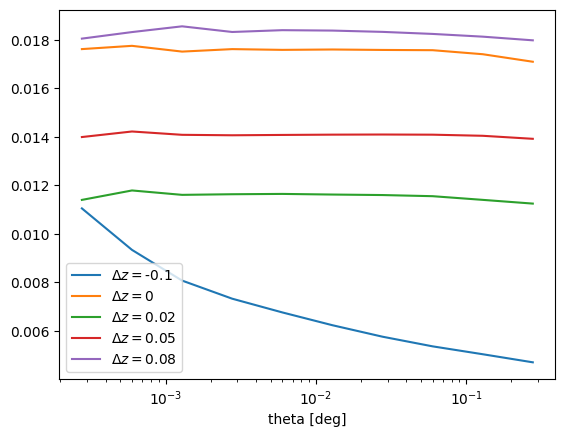

In [ ]:
for z_sep in [-0.2, 0, 0.02, 0.05, 0.08]:
    xi, varxi = get_NN_corr(config, z_sep)
    plt.plot(theta, varxi, label=r'$\Delta z = $' + f'{z_sep}')

plt.xscale('log')
plt.xlabel('theta [deg]')

plt.legend()
plt.show()
    